In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Load Data
df = pd.read_csv('salary_data_final_cleaned.csv')

# 2. Create Target: High=1, Low=0 based on median salary
median_salary = df['avg_salary'].median()
df['Salary_Class'] = np.where(df['avg_salary'] >= median_salary, 1, 0)

# 3. Select Features X and Target y
# Drop text columns + salary columns to avoid leakage
cols_to_drop = ['job_title', 'salary_estimate', 'job_description', 'company_name', 
                'company_txt', 'avg_salary', 'min_salary', 'max_salary', 'Salary_Class']
X = df.drop(cols_to_drop, axis=1)
y = df['Salary_Class']

# 4. Convert all text columns to numbers
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

# 5. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Scale the data - important for Logistic Regression
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 7. Train Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# 8. Predict and Check Accuracy
y_pred = model.predict(X_test)
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Low Salary', 'High Salary']))

Accuracy: 59.57 %

Classification Report:
              precision    recall  f1-score   support

  Low Salary       0.53      0.66      0.59        41
 High Salary       0.67      0.55      0.60        53

    accuracy                           0.60        94
   macro avg       0.60      0.60      0.60        94
weighted avg       0.61      0.60      0.60        94



C:\Users\Jyoti\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


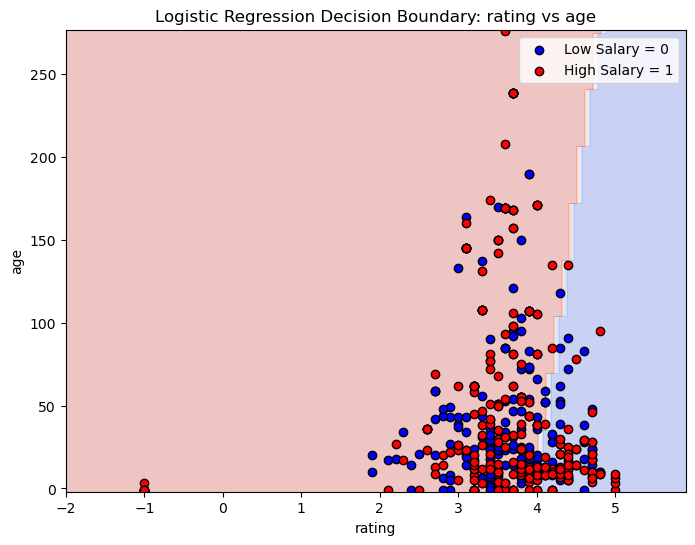

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Pick 2 features to plot. Let's use 'rating' and 'age'
# You can change these to any 2 numerical columns from X
feature1 = 'rating'
feature2 = 'age'

# 2. Get only those 2 features from original df for plotting
df_plot = df[[feature1, feature2, 'Salary_Class']].copy()
df_plot = df_plot.dropna()

X_plot = df_plot[[feature1, feature2]]
y_plot = df_plot['Salary_Class']

# 3. Train a new Logistic Regression only on these 2 features
model_2d = LogisticRegression(max_iter=1000)
model_2d.fit(X_plot, y_plot)

# 4. Create a mesh to plot the decision boundary
x_min, x_max = X_plot[feature1].min() - 1, X_plot[feature1].max() + 1
y_min, y_max = X_plot[feature2].min() - 1, X_plot[feature2].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plot
plt.figure(figsize=(8,6))

# Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

# Plot the data points
plt.scatter(X_plot[y_plot==0][feature1], X_plot[y_plot==0][feature2], 
            color='blue', label='Low Salary = 0', edgecolor='k')
plt.scatter(X_plot[y_plot==1][feature1], X_plot[y_plot==1][feature2], 
            color='red', label='High Salary = 1', edgecolor='k')

plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title(f'Logistic Regression Decision Boundary: {feature1} vs {feature2}')
plt.legend()
plt.show()